In [12]:
# !pip uninstall pybamm -y

In [13]:
# ! pip install -e.

In [1]:
# aktiviraj myenv okolje
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

## Nova koda

In [16]:
def my_current(t):
    return pybamm.sin( 2*np.pi * t *100)/1e1


In [17]:
# model, ki ima le mehansko degradacijo
model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        name="Meh.",)


param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)
param0["Current function [A]"] = my_current

param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)
param1["Current function [A]"] = my_current

param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 2e9},
    check_already_exists=False  
)
param2["Current function [A]"] = my_current

var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

# experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model_DFN, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model_DFN, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model_DFN, parameter_values=param2, var_pts=var_pts, solver=solver,#experiment=experiment 
                              )

######################
# t_eval = [0, 3600]
t_eval = np.linspace(0, 0.3, 1000)  # 1 hour simulation with 100 time points
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

KeyboardInterrupt: 

In [ ]:
sol_DFN.plot(["Voltage [V]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.003), Output()), _dom_classes=('…

In [ ]:
sol_DFN_1.plot(["Voltage [V]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.003), Output()), _dom_classes=('…

In [ ]:
sol_DFN_2.plot(["Voltage [V]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.003), Output()), _dom_classes=('…

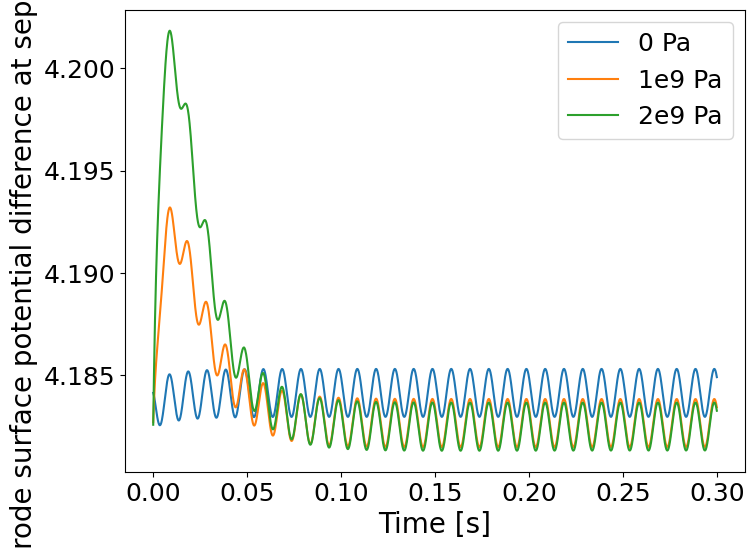

In [ ]:
voltage = sol_DFN["Voltage [V]"].entries 
voltage_1 = sol_DFN_1["Voltage [V]"].entries
voltage_2 = sol_DFN_2["Voltage [V]"].entries
x = sol_DFN["Time [s]"].entries
x_1 = sol_DFN_1["Time [s]"].entries
x_2 = sol_DFN_2["Time [s]"].entries

plt.figure(figsize=fig_size)
plt.plot(x, voltage, label="0 Pa")
plt.plot(x_1, voltage_1+0.0307, label="1e9 Pa")
plt.plot(x_2, voltage_2+0.0627, label="2e9 Pa")
plt.xlabel("Time [s]")
plt.ylabel("Negative electrode surface potential difference at separator interface [V]")
plt.legend()

In [ ]:
param0.search("electrolyte")

Results for 'electrolyte': ['EC initial concentration in electrolyte [mol.m-3]', 'Negative electrode Bruggeman coefficient (electrolyte)', 'Positive electrode Bruggeman coefficient (electrolyte)', 'Separator Bruggeman coefficient (electrolyte)', 'Initial concentration in electrolyte [mol.m-3]', 'Electrolyte diffusivity [m2.s-1]', 'Electrolyte conductivity [S.m-1]']
EC initial concentration in electrolyte [mol.m-3] -> 4541.0
Negative electrode Bruggeman coefficient (electrolyte) -> 2.914
Positive electrode Bruggeman coefficient (electrolyte) -> 1.83
Separator Bruggeman coefficient (electrolyte) -> 1.5
Initial concentration in electrolyte [mol.m-3] -> 1000.0
Electrolyte diffusivity [m2.s-1] -> <function electrolyte_diffusivity_Ai2020 at 0x000001B77770F880>
Electrolyte conductivity [S.m-1] -> <function electrolyte_conductivity_Ai2020 at 0x000001B77770F380>


In [ ]:
model_DFN.variables.search("electrode potential")

Results for 'electrode potential': ['Negative electrode potential [V]', 'X-averaged negative electrode potential [V]', 'Gradient of negative electrode potential [V.m-1]', 'Positive electrode potential [V]', 'X-averaged positive electrode potential [V]', 'Gradient of positive electrode potential [V.m-1]']


In [ ]:
Q = param0["Nominal cell capacity [A.h]"]
I = 0.001

C = I / Q
C

0.00043859649122807024

In [ ]:
output= ["Positive electrode surface potential difference at separator interface [V]", "Negative electrode surface potential difference at separator interface [V]"]
sol_DFN.plot(output_variables=output)

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.003), Output()), _dom_classes=('…

Text(0, 0.5, 'Negative electrode surface potential difference at separator interface [V]')

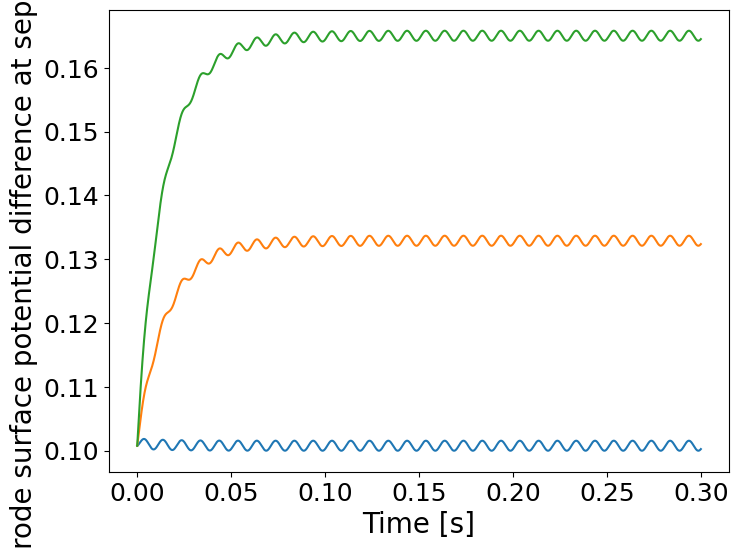

In [ ]:
phi = sol_DFN["Negative electrode surface potential difference at separator interface [V]"].entries 
phi_1 = sol_DFN_1["Negative electrode surface potential difference at separator interface [V]"].entries
phi_2 = sol_DFN_2["Negative electrode surface potential difference at separator interface [V]"].entries
x = sol_DFN["Time [s]"].entries
x_1 = sol_DFN_1["Time [s]"].entries
x_2 = sol_DFN_2["Time [s]"].entries

plt.figure(figsize=fig_size)
plt.plot(x, phi, label="Negative electrode surface potential difference at separator interface [V]")
plt.plot(x_1, phi_1, label="Negative electrode surface potential difference at separator interface [V] with 1e9 Pa")
plt.plot(x_2, phi_2, label="Negative electrode surface potential difference at separator interface [V] with 2e9 Pa")
plt.xlabel("Time [s]")
plt.ylabel("Negative electrode surface potential difference at separator interface [V]")

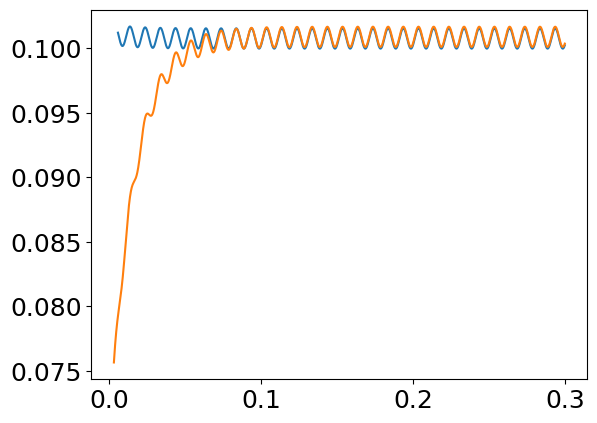

In [ ]:
plt.plot(x[100:], phi[100:], label="Positive electrode surface potential difference at separator interface [V]") # 4mV
plt.plot(x_1[100:], phi_1[100:]-0.032, label="Positive electrode surface potential difference at separator interface [V] with 1e9 Pa") #4 mV

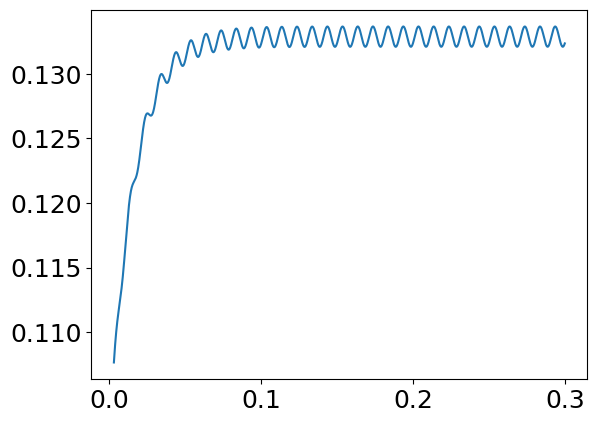

In [ ]:
plt.plot(x_1[100:], phi_1[100:], label="Negative electrode surface potential difference at separator interface [V] with 1e9 Pa") #4 mV

In [ ]:
sol_DFN_1.plot(output_variables=output)

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.003), Output()), _dom_classes=('…

In [ ]:
sol_DFN_2.plot(output_variables=output)

interactive(children=(FloatSlider(value=0.0, description='t', max=0.3, step=0.003), Output()), _dom_classes=('…

In [ ]:
# output= ["Positive electrode potential [V]", "Negative electrode potential [V]"]
# sol_DFN.plot(output_variables=output)

In [ ]:
param1.search("capacity")

Results for 'capacity': ['Negative current collector specific heat capacity [J.kg-1.K-1]', 'Positive current collector specific heat capacity [J.kg-1.K-1]', 'Nominal cell capacity [A.h]', 'Negative electrode double-layer capacity [F.m-2]', 'Negative electrode specific heat capacity [J.kg-1.K-1]', 'Positive electrode double-layer capacity [F.m-2]', 'Positive electrode specific heat capacity [J.kg-1.K-1]', 'Separator specific heat capacity [J.kg-1.K-1]']
Negative current collector specific heat capacity [J.kg-1.K-1] -> 385.0
Positive current collector specific heat capacity [J.kg-1.K-1] -> 897.0
Nominal cell capacity [A.h] -> 2.28
Negative electrode double-layer capacity [F.m-2] -> 0.2
Negative electrode specific heat capacity [J.kg-1.K-1] -> 1080.2
Positive electrode double-layer capacity [F.m-2] -> 0.2
Positive electrode specific heat capacity [J.kg-1.K-1] -> 1080.2
Separator specific heat capacity [J.kg-1.K-1] -> 1080.2


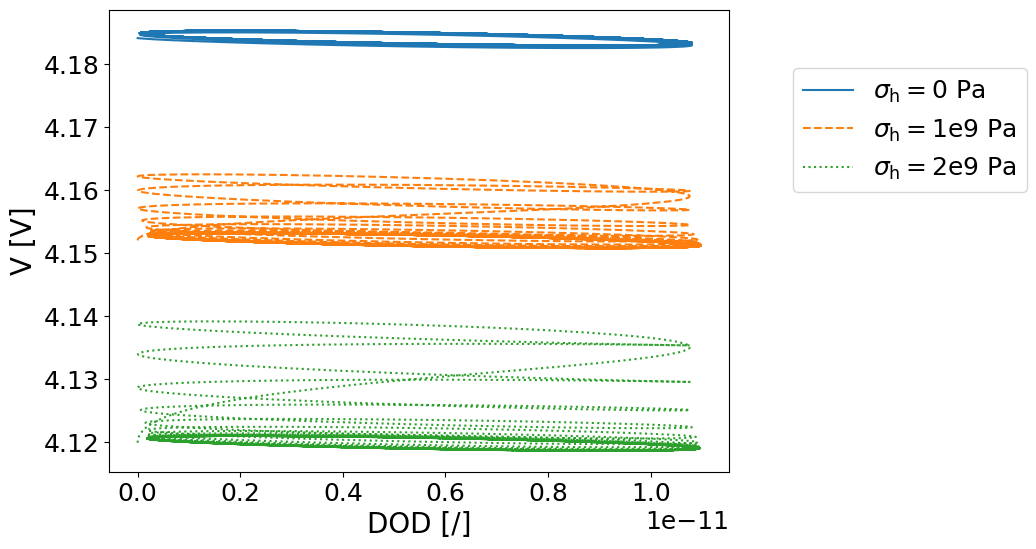

In [ ]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD_1 = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD_2 = (Q_discharged / Q_max)

x_val = [DOD, 
         DOD_1,
        DOD_2
         ]
y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=["$\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$\sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$\sigma_{\mathrm{h}}=$2e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$1e9 Pa" , 
                                        # "$\sigma_{\mathrm{h}}=$2e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$4e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$6e9 Pa",
                                        # "$\sigma_{\mathrm{h}}=$8e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$1e10 Pa", 
                                        # # "$\sigma_{\mathrm{h}}=$1e11 Pa"
                                        ][i], 
                                        linestyle=["-", "--", ":", "-", "-", "-", "-", "-", "-", "-"][i])
    
# plt.xlim(3000, 3600)
# plt.ylim(3.5, 3.6)
plt.xlabel("DOD [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

if save_fig:
    plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


## Stara koda

In [19]:
# model, ki ima le mehansko degradacijo
model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",
                                                 },
                                        )

model_DFN2 = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                    "particle": "Fickian diffusion",        
                                                    "particle mechanics": "swelling only",
                                                    "intercalation kinetics": "asymmetric Butler-Volmer",
                                                    },
                                        )


param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0,
     "Negative electrode Butler-Volmer transfer coefficient":0.5,
     "Positive electrode Butler-Volmer transfer coefficient":0.5},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e9,
     "Negative electrode Butler-Volmer transfer coefficient":0.5,
     "Positive electrode Butler-Volmer transfer coefficient":0.5},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 2e9,
     "Negative electrode Butler-Volmer transfer coefficient":0.5,
     "Positive electrode Butler-Volmer transfer coefficient":0.5},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}


experiment = pybamm.Experiment(["Discharge at C/1000 until 3.0 V"])
solver = pybamm.IDAKLUSolver()  


sim_DFN_0 = pybamm.Simulation(model= model_DFN, parameter_values=param0, var_pts=var_pts, solver=solver, 
                              experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model_DFN, parameter_values=param1, var_pts=var_pts, solver=solver, 
                              experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model_DFN, parameter_values=param2, var_pts=var_pts, solver=solver, 
                              experiment=experiment 
                              )
sim_DFN2_0 = pybamm.Simulation(model= model_DFN2, parameter_values=param0, var_pts=var_pts, solver=solver,
                               experiment=experiment 
                              )
sim_DFN2_1 = pybamm.Simulation(model= model_DFN2, parameter_values=param1, var_pts=var_pts, solver=solver,
                               experiment=experiment 
                              )
sim_DFN2_2 = pybamm.Simulation(model= model_DFN2, parameter_values=param2, var_pts=var_pts, solver=solver,
                               experiment=experiment 
                              )
######################
t_eval = [0, 3600]
# t_eval = np.arange(0, 3601, 10)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

# start = time.time()
# # data_ox = sim_DFN2_0.solve(t_eval=t_eval)
# sol_DFN2_0 = sim_DFN2_0.solve(t_eval=t_eval)
# end = time.time()
# print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN2_1 = sim_DFN2_1.solve(t_eval=t_eval)
# end = time.time()
# print(f"Simulacija DFN2_1 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN2_2 = sim_DFN2_2.solve(t_eval=t_eval)    
# end = time.time()
# print(f"Simulacija DFN2_2 zaključena v {end - start:.2f} s.")


2025-08-30 12:54:01.850 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 3.32 s.


2025-08-30 12:54:04.937 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 3.03 s.


2025-08-30 12:54:07.780 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 2.92 s.


In [20]:
sol_DFN.save_data("sol_DFN_0Pa_C1000.csv", ["X-averaged negative electrode exchange current density [A.m-2]", 
                                      "X-averaged negative electrode reaction overpotential [V]", 
                                      "X-averaged negative electrode interfacial current density [A.m-2]",
                                      "X-averaged positive electrode exchange current density [A.m-2]", 
                                      "X-averaged positive electrode reaction overpotential [V]", 
                                      "X-averaged positive electrode interfacial current density [A.m-2]"], to_format="csv")

In [21]:
sol_DFN_1.save_data("sol_DFN_1GPa_C1000.csv", ["X-averaged negative electrode exchange current density [A.m-2]", 
                                      "X-averaged negative electrode reaction overpotential [V]", 
                                      "X-averaged negative electrode interfacial current density [A.m-2]",
                                      "X-averaged positive electrode exchange current density [A.m-2]", 
                                      "X-averaged positive electrode reaction overpotential [V]", 
                                      "X-averaged positive electrode interfacial current density [A.m-2]"], to_format="csv")

In [22]:
sol_DFN_2.save_data("sol_DFN_2GPa_C1000.csv", ["X-averaged negative electrode exchange current density [A.m-2]", 
                                      "X-averaged negative electrode reaction overpotential [V]", 
                                      "X-averaged negative electrode interfacial current density [A.m-2]",
                                      "X-averaged positive electrode exchange current density [A.m-2]", 
                                      "X-averaged positive electrode reaction overpotential [V]", 
                                      "X-averaged positive electrode interfacial current density [A.m-2]"], to_format="csv")

In [133]:
param0.search("initial")

Results for 'initial': ['Initial SEI thickness [m]', 'Initial SEI on cracks thickness [m]', 'EC initial concentration in electrolyte [mol.m-3]', 'Negative electrode initial crack length [m]', 'Negative electrode initial crack width [m]', 'Positive electrode initial crack length [m]', 'Positive electrode initial crack width [m]', 'Initial concentration in electrolyte [mol.m-3]', 'Initial concentration in negative electrode [mol.m-3]', 'Initial concentration in positive electrode [mol.m-3]', 'Initial temperature [K]']
Initial SEI thickness [m] -> 5e-09
Initial SEI on cracks thickness [m] -> 5e-13
EC initial concentration in electrolyte [mol.m-3] -> 4541.0
Negative electrode initial crack length [m] -> 2e-08
Negative electrode initial crack width [m] -> 1.5e-08
Positive electrode initial crack length [m] -> 2e-08
Positive electrode initial crack width [m] -> 1.5e-08
Initial concentration in electrolyte [mol.m-3] -> 1000.0
Initial concentration in negative electrode [mol.m-3] -> 24108.0
In

In [138]:
param0.search("c")

Results for 'c': ['Electron charge [C]', 'EC initial concentration in electrolyte [mol.m-3]', 'EC diffusivity [m2.s-1]', 'Cell cooling surface area [m2]', 'Cell volume [m3]', 'Cell emissivity', 'Cell thermal expansion coefficient [m.K-1]', 'Nominal cell capacity [A.h]', 'Negative electrode OCP [V]', 'Negative electrode OCP entropic change [V.K-1]', 'Positive electrode OCP [V]', 'Positive electrode OCP entropic change [V.K-1]', 'Number of electrodes connected in parallel to make a cell', 'Open-circuit voltage at 0% SOC [V]', 'Open-circuit voltage at 100% SOC [V]']
Electron charge [C] -> 1.602176634e-19
EC initial concentration in electrolyte [mol.m-3] -> 4541.0
EC diffusivity [m2.s-1] -> 2e-18
Cell cooling surface area [m2] -> 0.0060484
Cell volume [m3] -> 1.5341e-05
Cell emissivity -> 0.95
Cell thermal expansion coefficient [m.K-1] -> 1.1e-06
Nominal cell capacity [A.h] -> 2.28
Negative electrode OCP [V] -> <function graphite_ocp_Enertech_Ai2020 at 0x000001FA2F01DC60>
Negative electrod

In [136]:
sol_DFN["Negative electrode stoichiometry"].entries[1]*param0["Maximum concentration in negative electrode [mol.m-3]"]

24107.999999995

In [96]:
param0["Electrode height [m]"]*param0["Electrode width [m]"]*34

0.08149799999999999

In [91]:
model_DFN.variables.search("area")

Results for 'area': ['Negative electrode surface area to volume ratio [m-1]', 'X-averaged negative electrode surface area to volume ratio [m-1]', 'Positive electrode surface area to volume ratio [m-1]', 'X-averaged positive electrode surface area to volume ratio [m-1]', 'Ohmic heating per unit electrode-pair area [W.m-2]', 'Irreversible electrochemical heating per unit electrode-pair area [W.m-2]', 'Reversible heating per unit electrode-pair area [W.m-2]', 'Total heating per unit electrode-pair area [W.m-2]']


In [95]:
sol_DFN["Positive electrode stoichiometry"].entries[-1]

0.9653976230338478

In [94]:
sol_DFN["Positive electrode stoichiometry"].entries[1]

0.43499589532067173

In [93]:
sol_DFN["Negative electrode stoichiometry"].entries[-1]

0.006108475370630284

In [79]:
sol_DFN["Negative electrode stoichiometry"].entries[1]

0.8399999999999944

In [92]:
# constants
F_const = 96485.3365  # Faraday constant [As/mol]
 
# discharge capacity of the battery
Q_cell = 2.28  # [Ah]
Q_cell_As = Q_cell * 3600  # [As]
 
# cell (electrode) geometry
x_size_cell_cat = param0["Positive electrode thickness [m]"]       # width of the electrode (cathode) [m]
x_size_cell_ano = param0["Negative electrode thickness [m]"]      # width of the electrode (anode) [m]
y_size_cell     = param0["Electrode width [m]"]        # defined from the mesh [m]
z_size_cell_cat = param0["Electrode height [m]"]   # cathode size in z-direction [m]
z_size_cell_ano = param0["Electrode height [m]"]   # anode size in z-direction [m]
z_size_cell_avg = 0.5 * (z_size_cell_cat + z_size_cell_ano)  # average [m]
 
Vtot_cat = x_size_cell_cat * y_size_cell * z_size_cell_avg  # [m^3]
Vtot_ano = x_size_cell_ano * y_size_cell * z_size_cell_avg  # [m^3]
 
# cathode parameters
eps_cat     = param0["Positive electrode porosity"] # poroznost - delež lukenj
eps_cat_f   = 1-param0["Positive electrode porosity"]-param0["Positive electrode active material volume fraction"] # delež fillerjev
Cpmax_cat   = param0["Maximum concentration in positive electrode [mol.m-3]"] # max konc litija
theta0_cat  = sol_DFN["Positive electrode stoichiometry"].entries[-1]
theta1_cat  = sol_DFN["Positive electrode stoichiometry"].entries[1]
 
# anode parameters
eps_ano     =  param0["Negative electrode porosity"]
eps_ano_f   = 1-param0["Negative electrode porosity"]-param0["Negative electrode active material volume fraction"] # delež fillerjev
Cpmax_ano   = param0["Maximum concentration in negative electrode [mol.m-3]"] # max konc litija
theta0_ano  = sol_DFN["Negative electrode stoichiometry"].entries[-1]
theta1_ano  = sol_DFN["Negative electrode stoichiometry"].entries[1]
 
# calculation of maximal cathode/anode capacity [As]
n = 34 # no. of layers
Qmax_cat = n*(1.0 - eps_cat - eps_cat_f) * Vtot_cat * Cpmax_cat * (theta0_cat - theta1_cat) * F_const
Qmax_ano = n*(1.0 - eps_ano - eps_ano_f) * Vtot_ano * Cpmax_ano * (theta1_ano - theta0_ano) * F_const
 
# corrected parameters
eps_ano_corr = 1.0 - eps_ano_f - Qmax_cat / (Vtot_ano * Cpmax_ano * (theta1_ano - theta0_ano) * F_const)
eps_cat_corr = 1.0 - eps_cat_f - Q_cell_As / (Vtot_cat * Cpmax_cat * (theta0_cat - theta1_cat) * F_const)
 
x_size_cell_ano_corr = (
    Qmax_cat / (Cpmax_ano * (theta1_ano - theta0_ano) * F_const)
    / ((1.0 - eps_ano - eps_ano_f) * y_size_cell * z_size_cell_avg)
)
 
theta1_ano_corr = theta0_ano + Qmax_cat / ((1.0 - eps_ano - eps_ano_f) * Vtot_ano * Cpmax_ano) / F_const
theta1_cat_corr = theta0_cat - Qmax_cat / ((1.0 - eps_cat - eps_cat_f) * Vtot_cat * Cpmax_cat) / F_const
 
z_size_cell_corr = (
    Q_cell * 3600
    / ((1.0 - eps_cat - eps_cat_f) * x_size_cell_cat * y_size_cell * Cpmax_cat * (theta0_cat - theta1_cat) * F_const)
)
 
# display results
print("---- Battery model rescalation ----")
print(f"Cathode capacity in model: {Qmax_cat/3600:.4f} Ah")
print(f"Anode capacity in model: {Qmax_ano/3600:.4f} Ah")
print(f"Corrected anode porosity: {eps_ano_corr:.6f}")
print(f"Corrected anode thickness: {x_size_cell_ano_corr*1e6:.4f} um")
print(f"Corrected cathode stoichiometry of cathode at SoC=1: {theta1_cat_corr:.6f}")
print(f"Corrected cathode porosity: {eps_cat_corr:.6f}")
print(f"Corrected anode stoichiometry of anode at SoC=1: {theta1_ano_corr:.6f}")
print(f"Corrected size of the cell in z-direction: {z_size_cell_corr:.6f} m")

---- Battery model rescalation ----
Cathode capacity in model: 2.4394 Ah
Anode capacity in model: 2.4394 Ah
Corrected anode porosity: -19.799877
Corrected anode thickness: 2600.9846 um
Corrected cathode stoichiometry of cathode at SoC=1: -17.068261
Corrected cathode porosity: -18.762418
Corrected anode stoichiometry of anode at SoC=1: 28.358253
Corrected size of the cell in z-direction: 1.620683 m


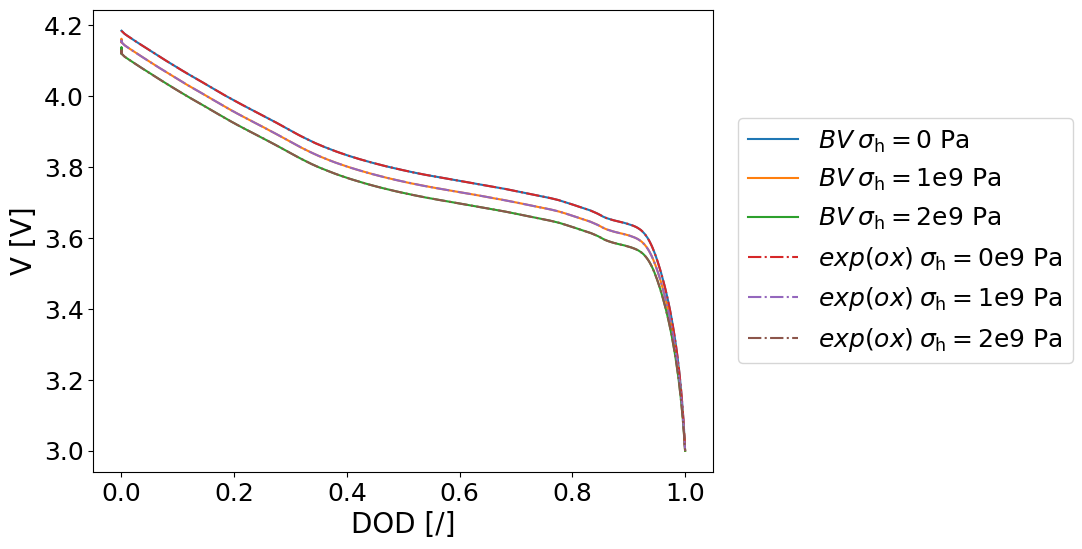

In [99]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)

Q_discharged = sol_DFN2_0["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_3 = (Q_discharged / Q_max)

Q_discharged = sol_DFN2_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_4 = (Q_discharged / Q_max)

Q_discharged = sol_DFN2_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_5 = (Q_discharged / Q_max)

x_val = [DOD, 
         DOD_1,
        DOD_2,
        DOD_3,
        DOD_4,
        DOD_5
         ]
y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
         sol_DFN_2["Voltage [V]"].data,
        sol_DFN2_0["Voltage [V]"].data,
        sol_DFN2_1["Voltage [V]"].data,
        sol_DFN2_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=["$BV \:\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$BV \: \sigma_{\mathrm{h}}=$2e9 Pa",
                                        "$exp(ox) \: \sigma_{\mathrm{h}}=$0e9 Pa", 
                                        "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$exp(ox) \: \sigma_{\mathrm{h}}=$2e9 Pa",
                                
                                        ][i], 
                                        linestyle=["-", "-", "-", "-.", "-.", "-.", "-", "-", "-", "-"][i])
    
# plt.xlim(3000, 3600)
# plt.ylim(3.5, 3.6)
plt.xlabel("DOD [/]")
plt.ylabel("V [V]")
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

if save_fig:
    plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


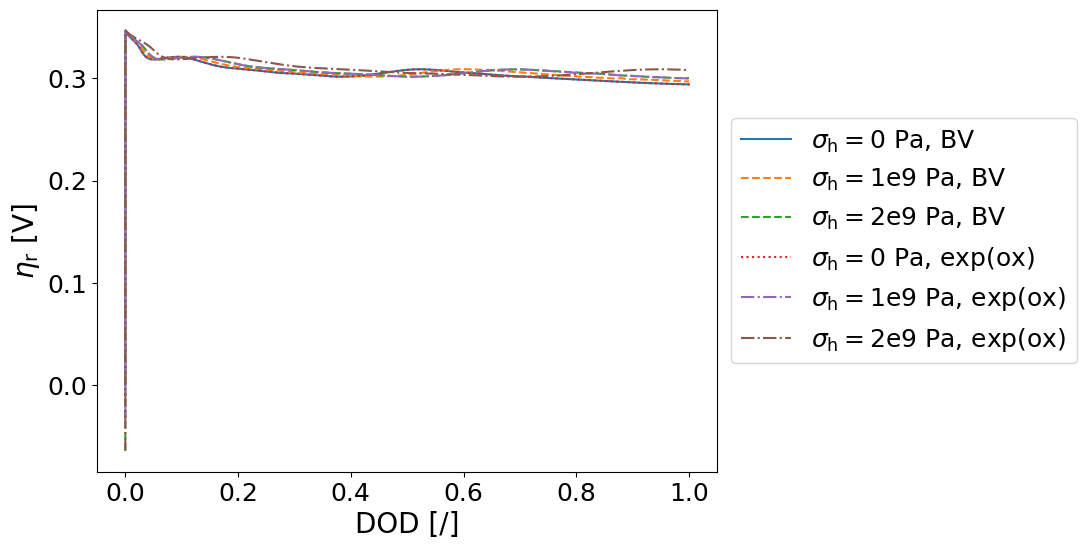

In [70]:
eta_r = [sol_DFN["Negative electrode reaction overpotential [V]"].entries[-1,:],
        sol_DFN_1["Negative electrode reaction overpotential [V]"].entries[-1,:],
        sol_DFN_2["Negative electrode reaction overpotential [V]"].entries[-1,:],
        sol_DFN2_0["Negative electrode reaction overpotential [V]"].entries[-1,:],
        sol_DFN2_1["Negative electrode reaction overpotential [V]"].entries[-1,:],
        sol_DFN2_2["Negative electrode reaction overpotential [V]"].entries[-1,:],
        ]

DODs = [DOD, 
         DOD_1,
        DOD_2,
        DOD_3,
        DOD_4,
        DOD_5
         ]    

labels = ["$\sigma_{\mathrm{h}}=$0 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$1e9 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$2e9 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$0 Pa, exp(ox)", 
          "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(ox)", 
          "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(ox)", 
         ]

plt.figure(figsize=fig_size)
for i in range(len(eta_r)):
    plt.plot(DODs[i], eta_r[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("$\eta_{\mathrm{r}}$ [V]")   
# plt.xlim(0.94, 1)
# plt.ylim(0.2, 0.35)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))


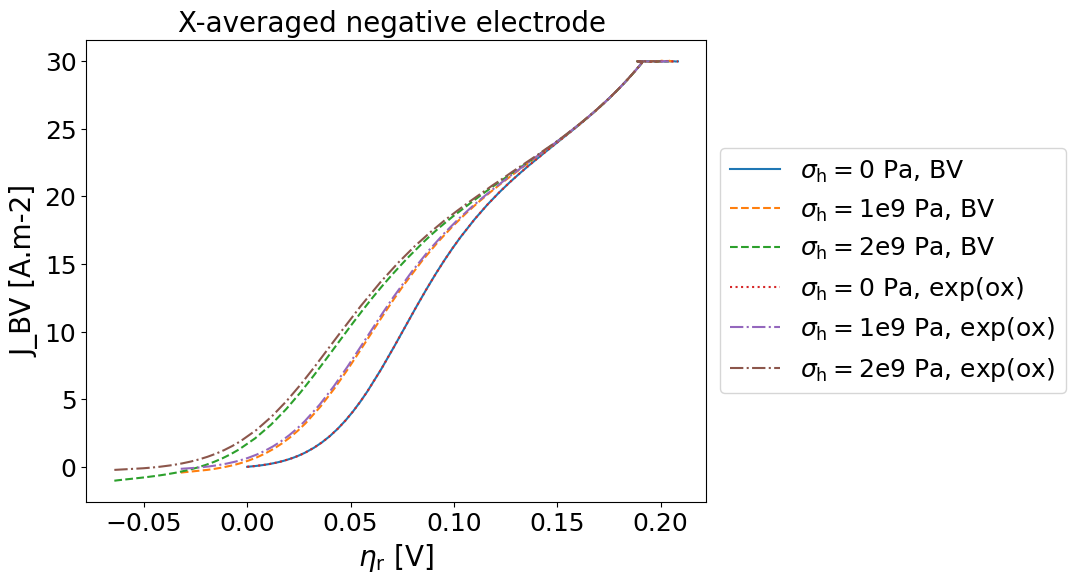

In [71]:
J_BV = [
    sol_DFN["X-averaged negative electrode interfacial current density [A.m-2]"].entries, # delec pri separatorju
    sol_DFN_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
]

eta_r = [sol_DFN["X-averaged negative electrode reaction overpotential [V]"].entries,
        sol_DFN_1["X-averaged negative electrode reaction overpotential [V]"].entries,
        sol_DFN_2["X-averaged negative electrode reaction overpotential [V]"].entries,
        sol_DFN2_0["X-averaged negative electrode reaction overpotential [V]"].entries,
        sol_DFN2_1["X-averaged negative electrode reaction overpotential [V]"].entries,
        sol_DFN2_2["X-averaged negative electrode reaction overpotential [V]"].entries,
        ]

DODs = [DOD, 
         DOD_1,
        DOD_2,
        DOD_3,
        DOD_4,
        DOD_5
         ]    

labels = ["$\sigma_{\mathrm{h}}=$0 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$1e9 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$2e9 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$0 Pa, exp(ox)", 
          "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(ox)", 
          "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(ox)", 
         ]

plt.figure(figsize=fig_size)
for i in range(len(eta_r)):
    plt.plot(eta_r[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.ylabel("J_BV [A.m-2]")
plt.xlabel("$\eta_{\mathrm{r}}$ [V]")   
plt.title("X-averaged negative electrode ")
# plt.xlim(0.94, 1)
# plt.ylim(0.28, 0.35)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))


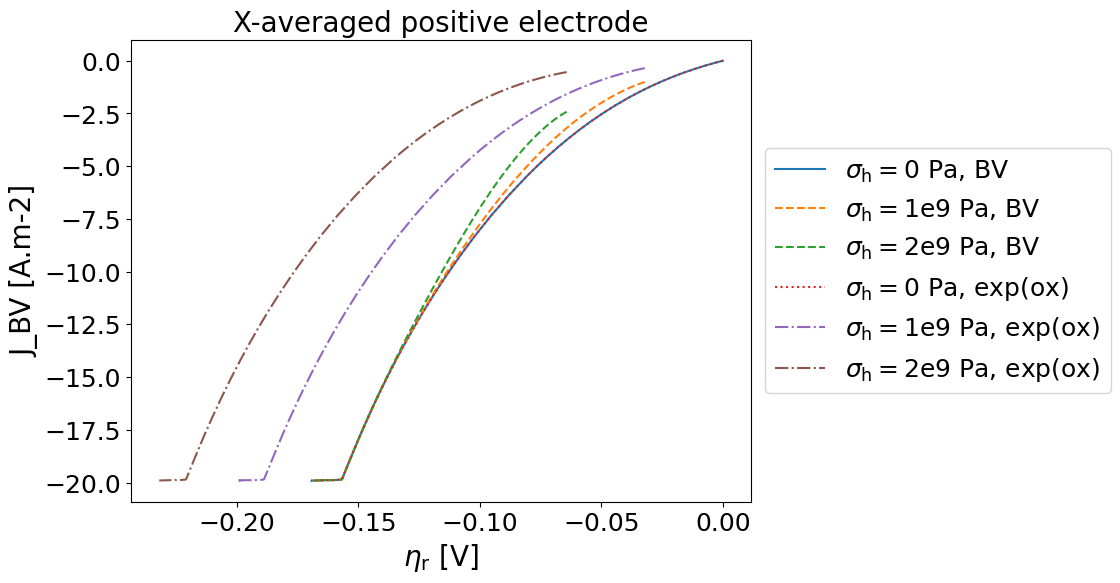

In [72]:
J_BV = [
    sol_DFN["X-averaged positive electrode interfacial current density [A.m-2]"].entries, # delec pri separatorju
    sol_DFN_1["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
]

eta_r = [sol_DFN["X-averaged positive electrode reaction overpotential [V]"].entries,
        sol_DFN_1["X-averaged positive electrode reaction overpotential [V]"].entries,
        sol_DFN_2["X-averaged positive electrode reaction overpotential [V]"].entries,
        sol_DFN2_0["X-averaged positive electrode reaction overpotential [V]"].entries,
        sol_DFN2_1["X-averaged positive electrode reaction overpotential [V]"].entries,
        sol_DFN2_2["X-averaged positive electrode reaction overpotential [V]"].entries,
        ]

DODs = [DOD, 
         DOD_1,
        DOD_2,
        DOD_3,
        DOD_4,
        DOD_5
         ]    

labels = ["$\sigma_{\mathrm{h}}=$0 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$1e9 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$2e9 Pa, BV", 
          "$\sigma_{\mathrm{h}}=$0 Pa, exp(ox)", 
          "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(ox)", 
          "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(ox)", 
         ]

plt.figure(figsize=fig_size)
for i in range(len(eta_r)):
    plt.plot(eta_r[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.ylabel("J_BV [A.m-2]")
plt.xlabel("$\eta_{\mathrm{r}}$ [V]")   
plt.title("X-averaged positive electrode")
# plt.xlim(0.94, 1)
# plt.ylim(0.28, 0.35)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))


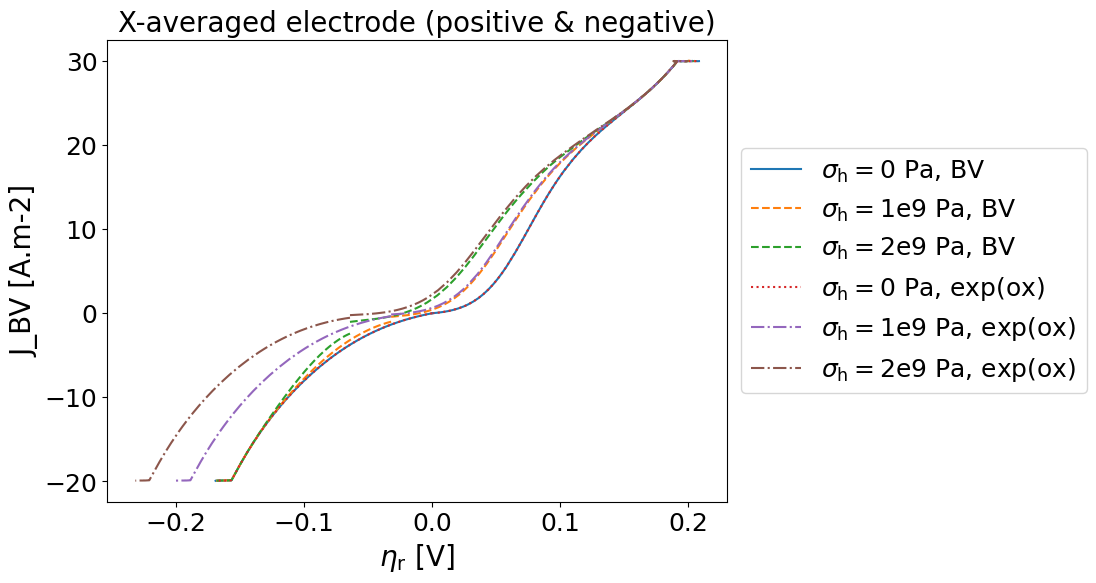

In [73]:
plt.figure(figsize=fig_size)

# Negative electrode
J_BV_neg = [
    sol_DFN["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
]

eta_r_neg = [
    sol_DFN["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN_1["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN_2["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN2_0["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN2_1["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN2_2["X-averaged negative electrode reaction overpotential [V]"].entries,
]

# Positive electrode
J_BV_pos = [
    sol_DFN["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_1["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
]

eta_r_pos = [
    sol_DFN["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN_1["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN_2["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN2_0["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN2_1["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN2_2["X-averaged positive electrode reaction overpotential [V]"].entries,
]

# Labels & linestyles
labels_neg = [
    "$\sigma_{\mathrm{h}}=$0 Pa, BV (neg)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, BV (neg)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, BV (neg)",
    "$\sigma_{\mathrm{h}}=$0 Pa, exp(red, neg)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(red, neg)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(red, neg)",
]

labels_pos = [
    "$\sigma_{\mathrm{h}}=$0 Pa, BV (pos)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, BV (pos)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, BV (pos)",
    "$\sigma_{\mathrm{h}}=$0 Pa, exp(red, pos)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(red, pos)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(red, pos)",
]

labels_ = [
    "$\sigma_{\mathrm{h}}=$0 Pa, BV",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, BV",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, BV",
    "$\sigma_{\mathrm{h}}=$0 Pa, exp(ox)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(ox)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(ox)",
]

linestyles = ["-", "--", "--", ":", "-.", "-."]
colors = ["C0", "C1", "C2", "C3", "C4", "C5"]


# Plot negative
for i in range(6):
    plt.plot(eta_r_neg[i], J_BV_neg[i], label=labels_[i], linestyle=linestyles[i], color=colors[i])

# Plot positive
for i in range(6):
    plt.plot(eta_r_pos[i], J_BV_pos[i], linestyle=linestyles[i], color=colors[i])

# Common formatting
plt.ylabel("J_BV [A.m-2]")
plt.xlabel("$\eta_{\mathrm{r}}$ [V]")   
plt.title("X-averaged electrode (positive & negative)")
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))
plt.show()


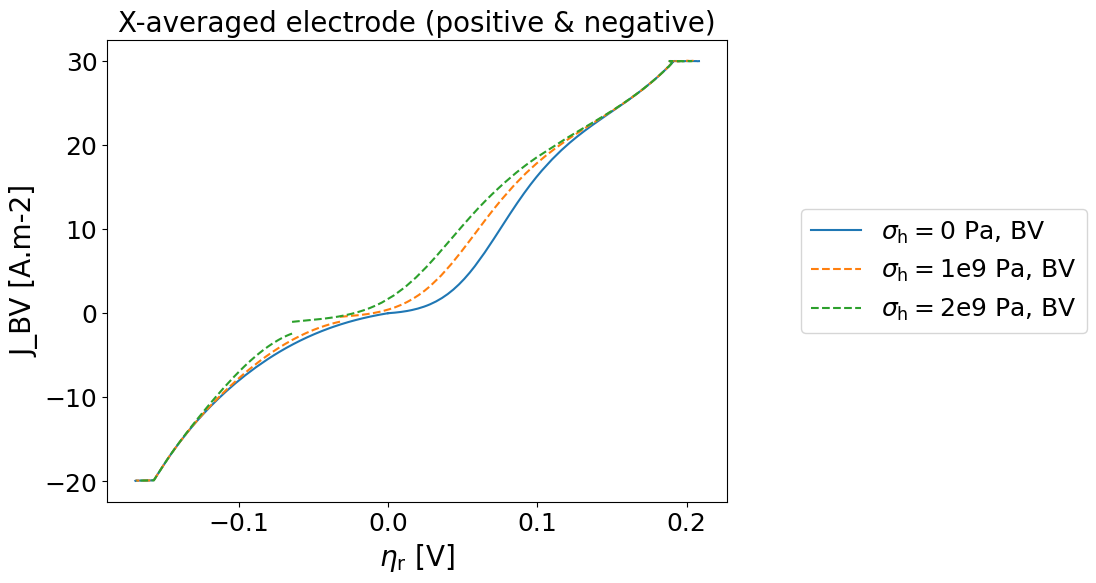

In [74]:
plt.figure(figsize=fig_size)

# Negative electrode
J_BV_neg = [
    sol_DFN["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged negative electrode interfacial current density [A.m-2]"].entries,
]

eta_r_neg = [
    sol_DFN["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN_1["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN_2["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN2_0["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN2_1["X-averaged negative electrode reaction overpotential [V]"].entries,
    sol_DFN2_2["X-averaged negative electrode reaction overpotential [V]"].entries,
]

# Positive electrode
J_BV_pos = [
    sol_DFN["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_1["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged positive electrode interfacial current density [A.m-2]"].entries,
]

eta_r_pos = [
    sol_DFN["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN_1["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN_2["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN2_0["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN2_1["X-averaged positive electrode reaction overpotential [V]"].entries,
    sol_DFN2_2["X-averaged positive electrode reaction overpotential [V]"].entries,
]

# Labels & linestyles
labels_neg = [
    "$\sigma_{\mathrm{h}}=$0 Pa, BV (neg)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, BV (neg)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, BV (neg)",
    "$\sigma_{\mathrm{h}}=$0 Pa, exp(red, neg)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(red, neg)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(red, neg)",
]

labels_pos = [
    "$\sigma_{\mathrm{h}}=$0 Pa, BV (pos)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, BV (pos)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, BV (pos)",
    "$\sigma_{\mathrm{h}}=$0 Pa, exp(red, pos)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(red, pos)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(red, pos)",
]

labels_ = [
    "$\sigma_{\mathrm{h}}=$0 Pa, BV",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, BV",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, BV",
    "$\sigma_{\mathrm{h}}=$0 Pa, exp(ox)",
    "$\sigma_{\mathrm{h}}=$1e9 Pa, exp(ox)",
    "$\sigma_{\mathrm{h}}=$2e9 Pa, exp(ox)",
]

linestyles = ["-", "--", "--", ":", "-.", "-."]
colors = ["C0", "C1", "C2", "C3", "C4", "C5"]


# Plot negative
for i in range(3):
    plt.plot(eta_r_neg[i], J_BV_neg[i], label=labels_[i], linestyle=linestyles[i], color=colors[i])

# Plot positive
for i in range(3):
    plt.plot(eta_r_pos[i], J_BV_pos[i], linestyle=linestyles[i], color=colors[i])

# Common formatting
plt.ylabel("J_BV [A.m-2]")
plt.xlabel("$\eta_{\mathrm{r}}$ [V]")   
plt.title("X-averaged electrode (positive & negative)")
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))
plt.show()


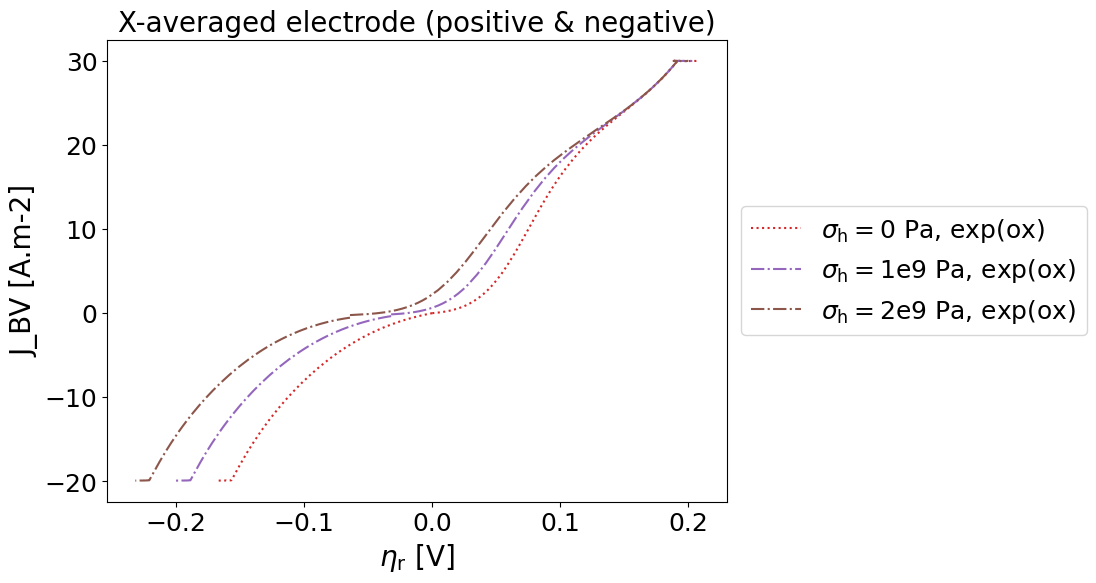

In [75]:
plt.figure(figsize=fig_size)
# Plot negative
for i in range(3,6):
    plt.plot(eta_r_neg[i], J_BV_neg[i], label=labels_[i], linestyle=linestyles[i], color=colors[i])

# Plot positive
for i in range(3,6):
    plt.plot(eta_r_pos[i], J_BV_pos[i], linestyle=linestyles[i], color=colors[i])

# Common formatting
plt.ylabel("J_BV [A.m-2]")
plt.xlabel("$\eta_{\mathrm{r}}$ [V]")   
plt.title("X-averaged electrode (positive & negative)")
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))
plt.show()


In [56]:
model_DFN.variables.search("ohm.m2")

Results for 'ohm.m2': ['X-averaged negative electrode resistance [Ohm.m2]', 'X-averaged positive electrode resistance [Ohm.m2]']


In [46]:
sol_DFN["X-averaged negative electrode resistance [Ohm.m2]"].entries[1]

0.0

In [51]:
sol_DFN.plot(["Resistance [Ohm]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0501975360262104, step=0.01050197536026210…

In [50]:
sol_DFN.plot(["Local ECM resistance [Ohm]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0501975360262104, step=0.01050197536026210…

In [52]:
sol_DFN.plot(["X-averaged positive electrode resistance [Ohm.m2]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0501975360262104, step=0.01050197536026210…

In [ ]:
sol_DFN.plot(["Positive electrode reaction overpotential [V]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=15.276290573189648, step=0.1527629057318965)…

In [ ]:
sol_DFN.plot(["Negative electrode interfacial current density [A.m-2]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0501975360262104, step=0.01050197536026210…

In [ ]:
sol_DFN.plot(["Positive electrode interfacial current density [A.m-2]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0501975360262104, step=0.01050197536026210…

In [ ]:
# # save to pickle file

# sol_DFN2_1.save_data(
#     "exp(ox).pickle",
#     ["Discharge capacity [A.h]", "Voltage [V]", "Negative electrode interfacial current density [A.m-2]", "Negative electrode exchange current density [A.m-2]"],
# )

# # extract data from pickle file
# import pickle

# # Replace with your actual file path
# file_path = 'exp(ox).pickle'

# with open(file_path, 'rb') as file:
#     data_ox = pickle.load(file)

# # Now `data` contains the deserialized object
# print(type(data_ox))
# print(data_ox)

<class 'dict'>
{'Discharge capacity [A.h]': array([0.00000000e+00, 7.16793544e-11, 1.43358709e-10, 2.86717418e-10,
       5.73434835e-10, 1.14686967e-09, 1.72030451e-09, 2.86717418e-09,
       4.01404385e-09, 5.16091352e-09, 6.30778319e-09, 8.60152253e-09,
       1.08952619e-08, 1.48525812e-08, 1.84141686e-08, 2.19757560e-08,
       2.55373434e-08, 2.90989308e-08, 3.62221056e-08, 4.33452803e-08,
       5.44608487e-08, 6.44648602e-08, 7.44688718e-08, 8.44728833e-08,
       9.44768948e-08, 1.14484918e-07, 1.34492941e-07, 1.60874612e-07,
       1.87256283e-07, 2.13637955e-07, 2.40019626e-07, 2.66401297e-07,
       2.92782968e-07, 3.45546311e-07, 3.98309654e-07, 4.51072996e-07,
       5.03836339e-07, 5.56599681e-07, 6.62126366e-07, 7.67653051e-07,
       8.73179736e-07, 9.78706421e-07, 1.08423311e-06, 1.18975979e-06,
       1.40081316e-06, 1.61186653e-06, 1.82291990e-06, 2.03397327e-06,
       2.24502664e-06, 2.45608001e-06, 2.87818675e-06, 3.30029349e-06,
       3.72240023e-06, 4.14450697

In [ ]:
# Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
# DOD = (Q_discharged / Q_max)

# Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
# DOD_1 = (Q_discharged / Q_max)

# Q_discharged = data_ox["Discharge capacity [A.h]"]
# Q_max = Q_discharged[-1] 
# DOD_2 = (Q_discharged / Q_max)

# Q_discharged = sol_DFN2_1["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
# DOD_3 = (Q_discharged / Q_max)

# x_val = [DOD, 
#          DOD_1,
#         DOD_2,
#         DOD_3
#          ]
# y_val = [sol_DFN["Voltage [V]"].data, 
#          sol_DFN_1["Voltage [V]"].data,
#         data_ox["Voltage [V]"],
#         sol_DFN2_1["Voltage [V]"].data
#          ]

# plt.figure(figsize=fig_size)
# for i in range(len(x_val)):
#     plt.plot(x_val[i], y_val[i], label=["$BV \:\sigma_{\mathrm{h}}=$0 Pa", 
#                                         "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
#                                         "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
#                                         "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
                                
#                                         ][i], 
#                                         linestyle=["-", "-", ":", ":", "-", "-", "-", "-", "-", "-"][i])
    
# # plt.xlim(3000, 3600)
# # plt.ylim(3.5, 3.6)
# plt.xlabel("DOD [/]")
# plt.ylabel("V [V]")
# plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

# if save_fig:
#     plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


In [ ]:
# J_BV = [
#     sol_DFN["Negative electrode interfacial current density [A.m-2]"].entries[-1, :], # delec pri separatorju
#     sol_DFN_1["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
#     data_ox["Negative electrode interfacial current density [A.m-2]"][-1, :],
#     sol_DFN2_1["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
# ]

# DODs = [
#     DOD[:],
#     DOD_1[:],
#     DOD_2[:],
#     DOD_3[:]
# ]

# labels = [
#     "$BV \: \sigma_{\mathrm{h}}=$0 Pa", 
#     "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
#     "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
#     "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
# ]

# plt.figure(figsize=fig_size)
# for i in range(len(J_BV)):
#     plt.plot(DODs[i], J_BV[i], label=labels[i], linestyle=["-", "-.", "-", "-."][i])
# plt.xlabel("DOD [/]")
# plt.ylabel("J [A.m$^{-2}$]")   
# plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

# if save_fig:
#     plt.savefig("graphs/J_BV.eps", format='eps', dpi=600, bbox_inches='tight')

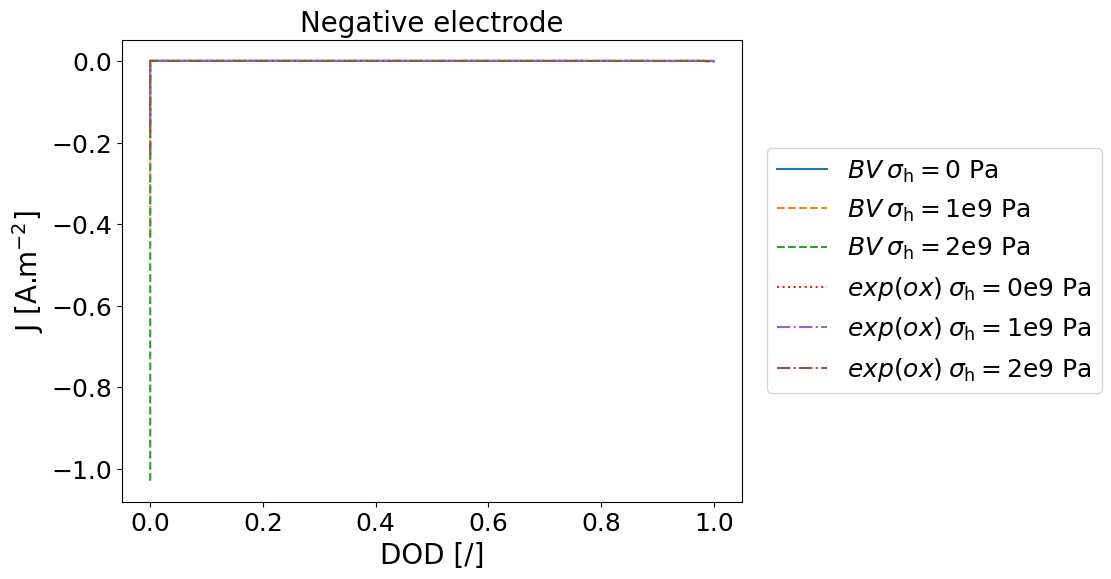

In [100]:
J_BV = [
    sol_DFN["Negative electrode interfacial current density [A.m-2]"].entries[-1, :], # delec pri separatorju
    sol_DFN_1["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
    sol_DFN_2["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
    sol_DFN2_0["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
    sol_DFN2_1["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
    sol_DFN2_2["Negative electrode interfacial current density [A.m-2]"].entries[-1, :],
]

DODs = [
    DOD[:],
    DOD_1[:],
    DOD_2[:],
    DOD_3[:],
    DOD_4[:],
    DOD_5
]

labels = [
    "$BV \: \sigma_{\mathrm{h}}=$0 Pa", 
    "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
    "$BV \: \sigma_{\mathrm{h}}=$2e9 Pa",
    "$exp(ox) \: \sigma_{\mathrm{h}}=$0e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$2e9 Pa",
]

plt.figure(figsize=fig_size)
for i in range(len(J_BV)):
    plt.plot(DODs[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J [A.m$^{-2}$]")  
plt.title("Negative electrode") 
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

if save_fig:
    plt.savefig("graphs/J_BV.eps", format='eps', dpi=600, bbox_inches='tight')

In [ ]:
J_bv= sol_DFN["X-averaged negative electrode interfacial current density [A.m-2]"].entries[-1]
eta_r = sol_DFN["X-averaged negative electrode reaction overpotential [V]"].entries[-1]
A = param0["Electrode height [m]"]*param0["Electrode width [m]"]*34

R1 = eta_r*2/J_bv/A

In [115]:
J_bv= sol_DFN_1["X-averaged negative electrode interfacial current density [A.m-2]"].entries[-1]
eta_r = sol_DFN_1["X-averaged negative electrode reaction overpotential [V]"].entries[-1]
A = param1["Electrode height [m]"]*param1["Electrode width [m]"]*34

R2 = eta_r*2/J_bv/A

In [116]:
R1/R2

1.0744148867036767

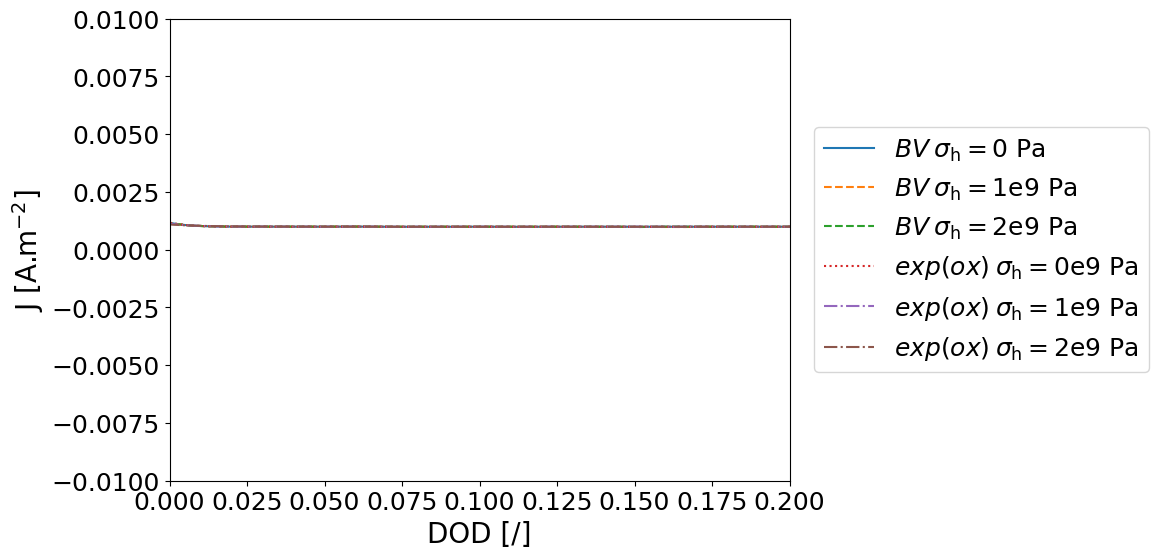

In [105]:
plt.figure(figsize=fig_size)
for i in range(len(J_BV)):
    plt.plot(DODs[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J [A.m$^{-2}$]")   
plt.xlim(0.0, 0.2)
plt.ylim(-0.01, 0.01)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))



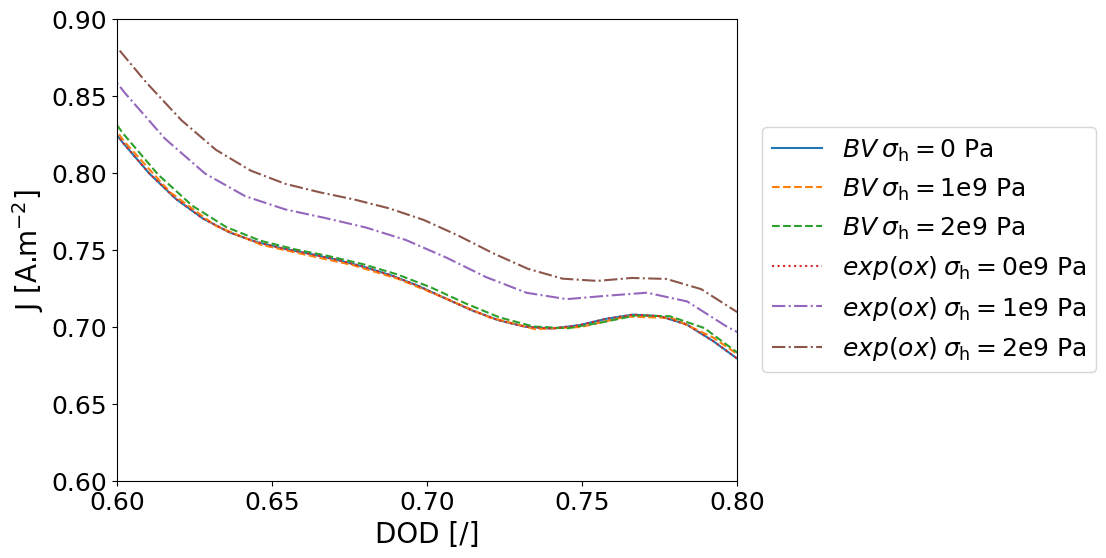

In [ ]:
plt.figure(figsize=fig_size)
for i in range(len(J_BV)):
    plt.plot(DODs[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J [A.m$^{-2}$]")   
plt.xlim(0.6, 0.8)
plt.ylim(0.6, 0.9)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

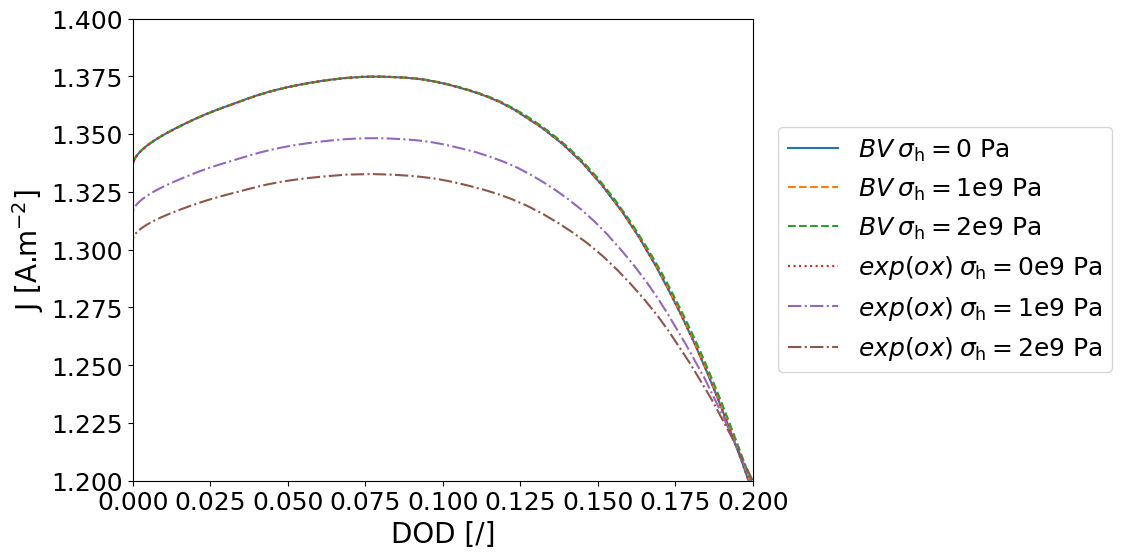

In [ ]:
plt.figure(figsize=fig_size)
for i in range(len(J_BV)):
    plt.plot(DODs[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J [A.m$^{-2}$]")   
plt.xlim(0, 0.2)
plt.ylim(1.2, 1.4)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

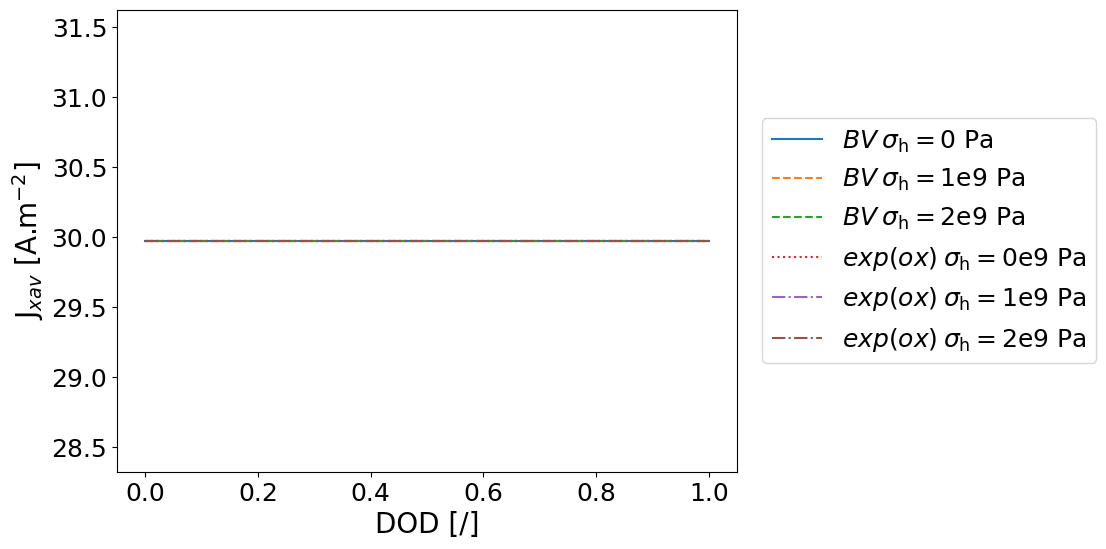

In [28]:
J_BV = [
    sol_DFN["X-averaged negative electrode total interfacial current density [A.m-2]"].entries, # delec pri separatorju
    sol_DFN_1["X-averaged negative electrode total interfacial current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged negative electrode total interfacial current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged negative electrode total interfacial current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged negative electrode total interfacial current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged negative electrode total interfacial current density [A.m-2]"].entries,
]

DODs = [
    DOD[:],
    DOD_1[:],
    DOD_2[:],
    DOD_3[:],
    DOD_4[:],
    DOD_5
]

labels = [
    "$BV \: \sigma_{\mathrm{h}}=$0 Pa", 
    "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
    "$BV \: \sigma_{\mathrm{h}}=$2e9 Pa",
    "$exp(ox) \: \sigma_{\mathrm{h}}=$0e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$2e9 Pa",
]

plt.figure(figsize=fig_size)
for i in range(len(J_BV)):
    plt.plot(DODs[i], J_BV[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J$_{xav}$ [A.m$^{-2}$]")   
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

if save_fig:
    plt.savefig("graphs/J_BV.eps", format='eps', dpi=600, bbox_inches='tight')

In [ ]:
# J_0 = [
#     sol_DFN["Negative electrode exchange current density [A.m-2]"].entries[-1, :], # delec pri separatorju
#     sol_DFN_1["Negative electrode exchange current density [A.m-2]"].entries[-1, :],
#     data_ox["Negative electrode exchange current density [A.m-2]"][-1, :],
#     sol_DFN2_1["Negative electrode exchange current density [A.m-2]"].entries[-1, :],
# ]

# DODs = [
#     DOD[:],
#     DOD_1[:],
#     DOD_2[:],
#     DOD_3[:]
# ]

# labels = [
#     "$BV \: \sigma_{\mathrm{h}}=$0 Pa", 
#     "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
#     "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
#     "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
# ]

# plt.figure(figsize=fig_size)
# for i in range(len(J_0)):
#     plt.plot(DODs[i], J_0[i], label=labels[i], linestyle=["-", "-.", "-", "-."][i])
# plt.xlabel("DOD [/]")
# plt.ylabel("J0 [A.m$^{-2}$]")   
# plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

# if save_fig:
#     plt.savefig("graphs/J_0.eps", format='eps', dpi=600, bbox_inches='tight')

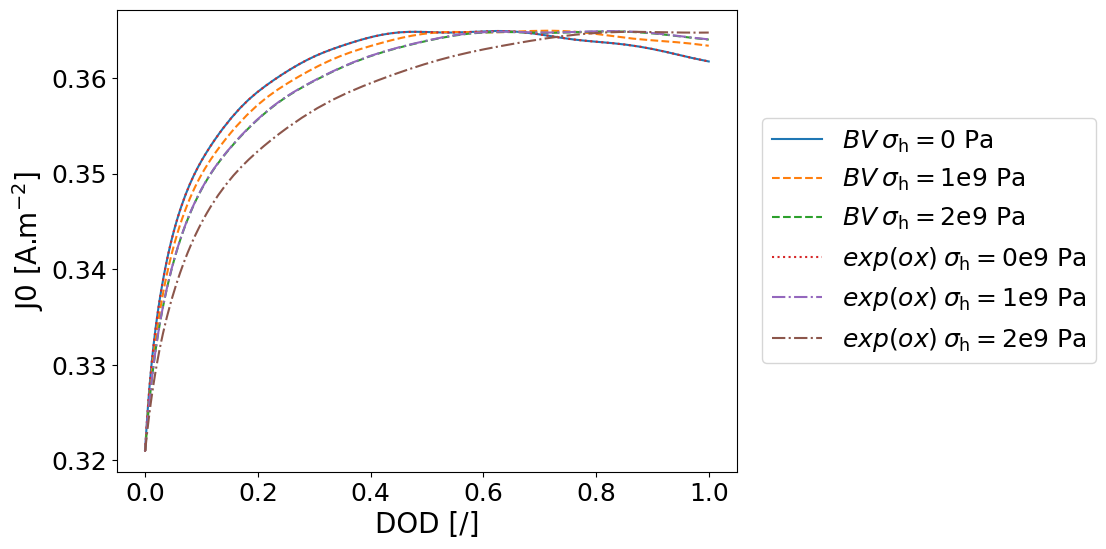

In [27]:
J_0 = [
    sol_DFN["X-averaged negative electrode exchange current density [A.m-2]"].entries, # delec pri separatorju
    sol_DFN_1["X-averaged negative electrode exchange current density [A.m-2]"].entries,
    sol_DFN_2["X-averaged negative electrode exchange current density [A.m-2]"].entries,
    sol_DFN2_0["X-averaged negative electrode exchange current density [A.m-2]"].entries,
    sol_DFN2_1["X-averaged negative electrode exchange current density [A.m-2]"].entries,
    sol_DFN2_2["X-averaged negative electrode exchange current density [A.m-2]"].entries
]

DODs = [
    DOD[:],
    DOD_1[:],
    DOD_2[:],
    DOD_3[:],
    DOD_4[:],
    DOD_5
]

labels = [
    "$BV \: \sigma_{\mathrm{h}}=$0 Pa", 
    "$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", 
    "$BV \: \sigma_{\mathrm{h}}=$2e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$0e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", 
    "$exp(ox) \: \sigma_{\mathrm{h}}=$2e9 Pa",
]

plt.figure(figsize=fig_size)
for i in range(len(J_0)):
    plt.plot(DODs[i], J_0[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J0 [A.m$^{-2}$]")   
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

if save_fig:
    plt.savefig("graphs/J_0.eps", format='eps', dpi=600, bbox_inches='tight')

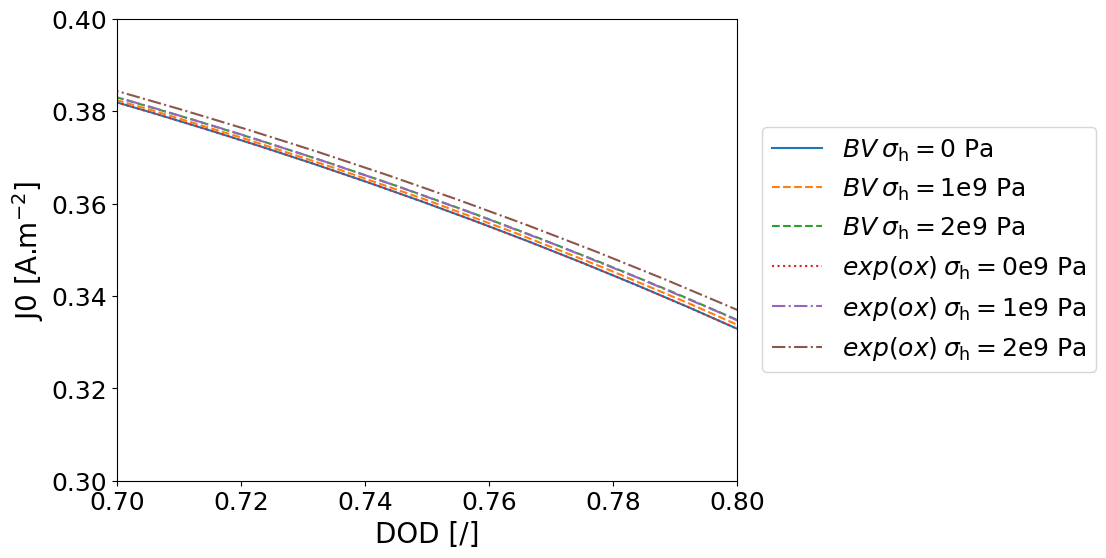

In [ ]:
plt.figure(figsize=fig_size)
for i in range(len(J_0)):
    plt.plot(DODs[i], J_0[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J0 [A.m$^{-2}$]")   
plt.xlim(0.7, 0.8)
plt.ylim(0.3, 0.4)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

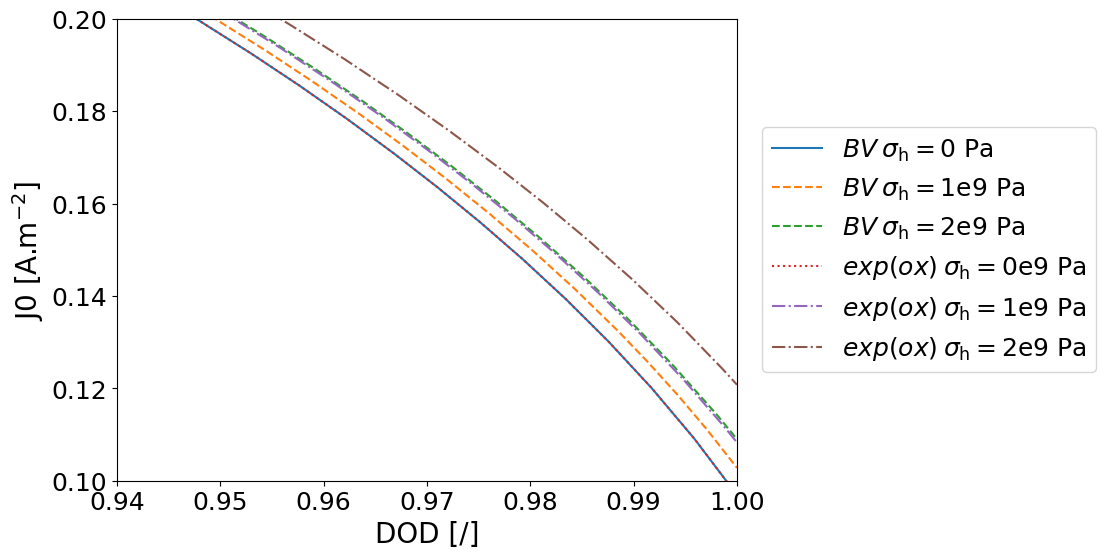

In [ ]:
plt.figure(figsize=fig_size)
for i in range(len(J_0)):
    plt.plot(DODs[i], J_0[i], label=labels[i], linestyle=["-", "--", "--", ":", "-.", "-."][i])
plt.xlabel("DOD [/]")
plt.ylabel("J0 [A.m$^{-2}$]")   
plt.xlim(0.94, 1)
plt.ylim(0.1, 0.2)
plt.legend(loc="center right", bbox_to_anchor=(1.6, 0.5))

## EIS

In [147]:
eis_sim_DFN = pybammeis.EISSimulation(model= model_DFN, parameter_values= param0)
eis_sim_DFN_1 = pybammeis.EISSimulation(model= model_DFN, parameter_values= param1)
eis_sim_DFN_2 = pybammeis.EISSimulation(model= model_DFN, parameter_values= param2)
eis_sim_DFN_3 = pybammeis.EISSimulation(model= model_DFN2, parameter_values= param0)
eis_sim_DFN_4 = pybammeis.EISSimulation(model= model_DFN2, parameter_values= param1)
eis_sim_DFN_5 = pybammeis.EISSimulation(model= model_DFN2, parameter_values= param2)

# eis_sim.solve(frequencies, inputs={"SOC": z})

frequencies = np.logspace(-4, 4, 30)
eis_sim_DFN.solve(frequencies)
eis_sim_DFN_1.solve(frequencies)
eis_sim_DFN_2.solve(frequencies)
eis_sim_DFN_3.solve(frequencies)
eis_sim_DFN_4.solve(frequencies)
eis_sim_DFN_5.solve(frequencies)

array([0.09288691-0.30385089j, 0.09285722-0.16138372j,
       0.0927732 -0.08623864j, 0.09249549-0.04701417j,
       0.09165935-0.02707608j, 0.08977264-0.01712625j,
       0.08721315-0.01156852j, 0.08495154-0.00804692j,
       0.08316134-0.00579452j, 0.08176097-0.00435566j,
       0.08066926-0.00348261j, 0.07984362-0.0030879j ,
       0.07927052-0.00328501j, 0.07885347-0.00446551j,
       0.07822557-0.00732122j, 0.07639398-0.01285523j,
       0.07077619-0.0217456j , 0.05730837-0.03102213j,
       0.03785133-0.03264011j, 0.02202724-0.02570414j,
       0.01354402-0.01688553j, 0.01000823-0.01058339j,
       0.00816176-0.00723798j, 0.00644099-0.00543462j,
       0.00489438-0.00409475j, 0.00371815-0.00304304j,
       0.00285876-0.00225506j, 0.00221813-0.00167852j,
       0.00173242-0.00124739j, 0.0013652 -0.00091049j])

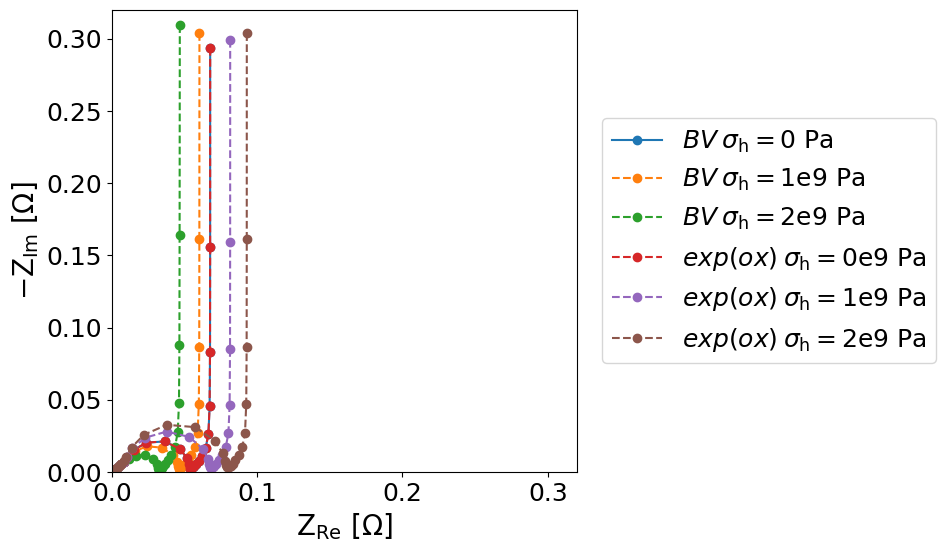

In [153]:
fig, ax = plt.subplots(figsize=(6, 6))

# narišemo Nyquistove diagrame
eis_sim_DFN.nyquist_plot(ax=ax, label="$BV \: \sigma_{\mathrm{h}}=$0 Pa", linestyle="-")
eis_sim_DFN_1.nyquist_plot(ax=ax, label="$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", linestyle="--")
eis_sim_DFN_2.nyquist_plot(ax=ax, label="$BV \: \sigma_{\mathrm{h}}=$2e9 Pa", linestyle="--")
eis_sim_DFN_3.nyquist_plot(ax=ax, label="$exp(ox) \: \sigma_{\mathrm{h}}=$0e9 Pa", linestyle="--")
eis_sim_DFN_4.nyquist_plot(ax=ax, label="$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", linestyle="--")
eis_sim_DFN_5.nyquist_plot(ax=ax, label="$exp(ox) \: \sigma_{\mathrm{h}}=$2e9 Pa", linestyle="--")


# onemogočimo "enako" merilo osi,
# da figsize=(8,6) dejansko določi razmerje width:height
ax.set_aspect("auto")

# omejimo realni del
ax.set_xlim(0, 0.32)
ax.set_ylim(0, 0.32)

# zdaj prikažemo legendo
ax.legend(loc="center right", bbox_to_anchor=(1.8, 0.5))

#title
ax.set_xlabel("$\mathrm{Z_{Re}}$ [Ω]")
ax.set_ylabel("$\mathrm{-Z_{Im}}$ [Ω]")


if save_fig:
    plt.savefig("graphs/EIS_i0_cel.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()

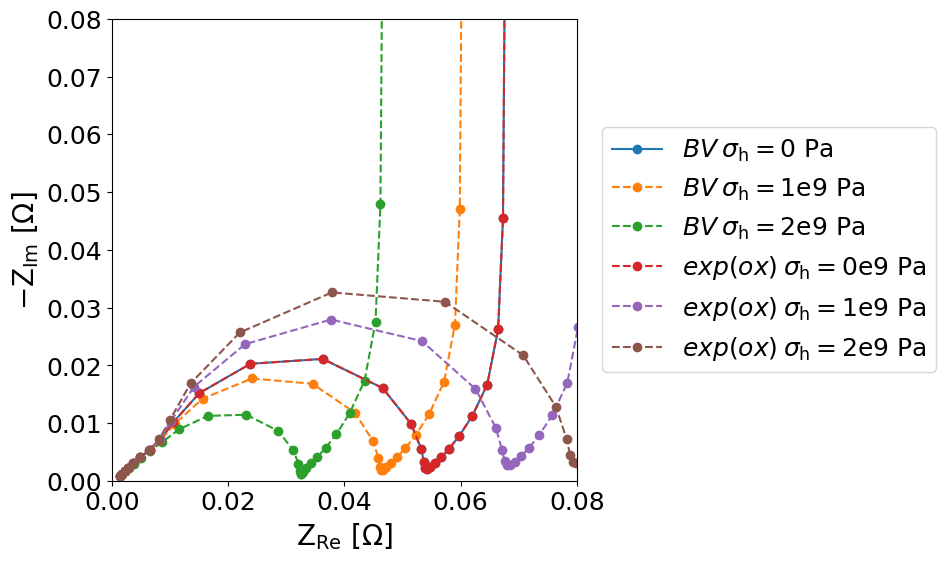

In [149]:
fig, ax = plt.subplots(figsize=(6, 6))

# narišemo Nyquistove diagrame
eis_sim_DFN.nyquist_plot(ax=ax, label="$BV \: \sigma_{\mathrm{h}}=$0 Pa", linestyle="-")
eis_sim_DFN_1.nyquist_plot(ax=ax, label="$BV \: \sigma_{\mathrm{h}}=$1e9 Pa", linestyle="--")
eis_sim_DFN_2.nyquist_plot(ax=ax, label="$BV \: \sigma_{\mathrm{h}}=$2e9 Pa", linestyle="--")
eis_sim_DFN_3.nyquist_plot(ax=ax, label="$exp(ox) \: \sigma_{\mathrm{h}}=$0e9 Pa", linestyle="--")
eis_sim_DFN_4.nyquist_plot(ax=ax, label="$exp(ox) \: \sigma_{\mathrm{h}}=$1e9 Pa", linestyle="--")
eis_sim_DFN_5.nyquist_plot(ax=ax, label="$exp(ox) \: \sigma_{\mathrm{h}}=$2e9 Pa", linestyle="--")




# onemogočimo "enako" merilo osi,
# da figsize=(8,6) dejansko določi razmerje width:height
ax.set_aspect("auto")

# omejimo realni del
ax.set_xlim(0, 0.08)
ax.set_ylim(0, 0.08)

# zdaj prikažemo legendo
ax.legend(loc="center right", bbox_to_anchor=(1.8, 0.5))

#title
ax.set_xlabel("$\mathrm{Z_{Re}}$ [Ω]")
ax.set_ylabel("$\mathrm{-Z_{Im}}$ [Ω]")

if save_fig:
    plt.savefig("graphs/EIS_i0_visoke_f.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()